In [ ]:
from models.test_modules import FCBlock
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import torch.optim
import deepwave
from deepwave import scalar
import time
import pickle
import scipy.stats as st
dtype = torch.cuda.FloatTensor
import sys
import os
import scipy.io as scio
import math

device = torch.device('cuda' if torch.cuda.is_available()
                      else 'cpu')


path= './nerf/test_with_patch_300k/'
if(not os.path.exists(path)):
    os.mkdir(path)

# Parameter setting

In [2]:
nx = 400
ny = 400

physics_size = 0.233 # m
dx = physics_size/nx

physics_time = 0.20e-3
Nt = 3000      # 4000
dt = physics_time/Nt
f0 = 300e3

Num_src = 64
Num_rec = 256

In [3]:
# 生成声源信号
def generate_Ricker(f0,dt,Nt):
    a = (torch.pi) * (torch.pi) * f0 *f0
    t0 = 1/f0
    t = np.linspace(0, Nt-1, num=Nt)
    source = 1e8*(1 - 2 * a * (t * dt - t0) * (t * dt - t0)) * np.exp(-a * (t * dt - t0) * (t * dt - t0))
    source = source.astype(np.float32)
    source = torch.tensor(source)
    return source

# 生成环形发射阵列
def get_cycle_coor_for_src(R, Num_src, nx, ny):
    src_coord = torch.zeros(Num_src, 2, dtype=torch.long)
    for i in range(Num_src):
        angle = i * 2 * np.pi / Num_src
        src_coord[i,0] = torch.round(torch.tensor(nx / 2 - np.sin(angle) * R))
        src_coord[i,1] = torch.round(torch.tensor(ny / 2 - np.cos(angle) * R))
    return src_coord

# 生成环形接收阵列
def get_cycle_coor_for_rec(R, Num_rec, nx, ny):
    rec_coord = torch.zeros(Num_rec, 2, dtype=torch.long)
    for i in range(Num_rec):
        angle = i * 2 * np.pi / Num_rec
        rec_coord[i,0] = torch.round(torch.tensor(nx / 2 - np.sin(angle) * R))
        rec_coord[i,1] = torch.round(torch.tensor(ny / 2 - np.cos(angle) * R))
    return rec_coord


In [4]:
def TV_loss(x,TVLoss_weight):
    h_x = x.size()[0]
    w_x = x.size()[1]
    h_tv = torch.pow((x[1:,:]-x[:h_x-1,:]),2).sum()
    w_tv = torch.pow((x[:,1:]-x[:,:w_x-1]),2).sum()
    return TVLoss_weight*2*(h_tv/h_x+w_tv/w_x)


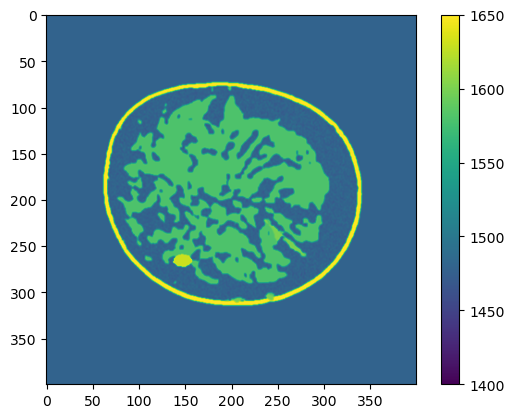

In [ ]:
R = nx*0.48       #200

source_coor = get_cycle_coor_for_src(R, Num_src, nx, ny)
rec_coor = get_cycle_coor_for_rec(R, Num_rec, nx, ny)
source_signal = generate_Ricker(f0,dt,Nt)

source_locations = torch.unsqueeze(source_coor, dim=1).long().to(device)

receiver_locations = torch.zeros(Num_src, Num_rec, 2,
                                  dtype=torch.long, device=device)
receiver_locations[:] = rec_coor.repeat(Num_src,1, 1)


source_amplitudes = source_signal.repeat(Num_src, 1, 1).to(device)

v_true = torch.from_file('./breast/phantom_400_short_Neg35_with_tumour.bin',
                      size=ny*nx, dtype = torch.short).reshape(ny, nx).to(device).T
v_true = v_true.float()

plt.imshow(v_true.cpu().numpy(),vmin = 1400, vmax = 1650)
plt.colorbar()
# plt.savefig(path + 'ground_truth.png')

# generate obs_data

In [6]:
# 生成观测信号
start_time = time.time()
out = scalar(v_true, dx, dt, source_amplitudes=source_amplitudes,
             source_locations=source_locations,
             receiver_locations=receiver_locations,
             accuracy=8,
             pml_freq=f0)
end_time = time.time()
print("耗时: {:.2f}秒".format(end_time - start_time))



耗时: 1.21秒


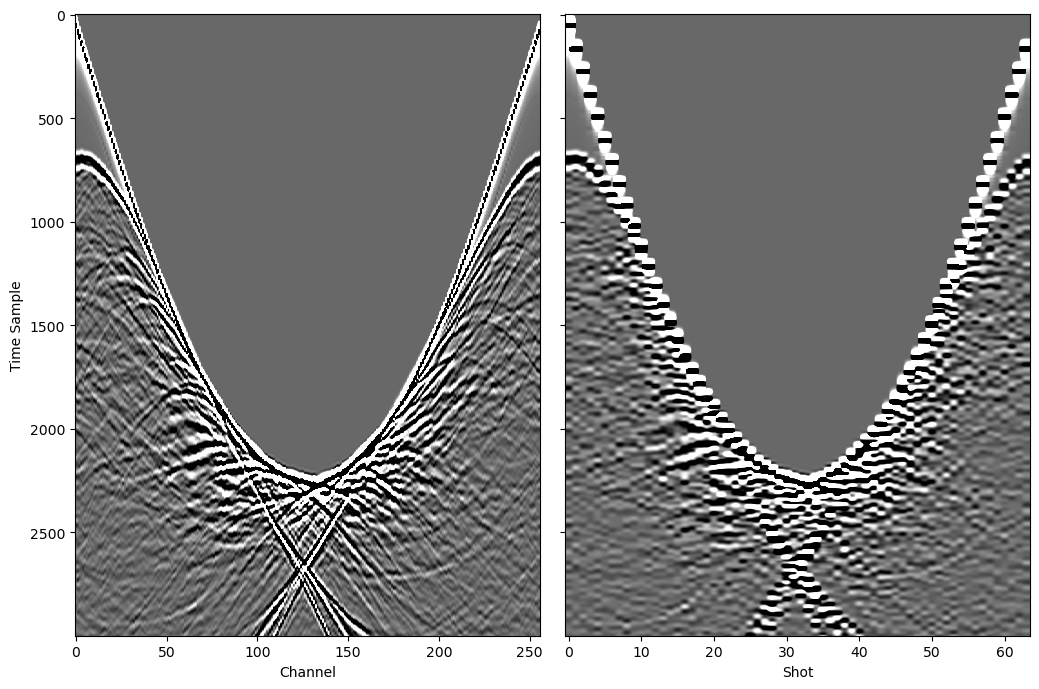

In [7]:
# 存储观测信号
receiver_amplitudes = out[-1]
vmin, vmax = torch.quantile(receiver_amplitudes[0],
                            torch.tensor([0.05, 0.95]).to(device))
_, ax = plt.subplots(1, 2, figsize=(10.5, 7), sharey=True)
ax[0].imshow(receiver_amplitudes[0].cpu().T, aspect='auto',
             cmap='gray', vmin=vmin, vmax=vmax)
ax[1].imshow(receiver_amplitudes[:, 0].cpu().T, aspect='auto',
             cmap='gray', vmin=vmin, vmax=vmax)
ax[0].set_xlabel("Channel")
ax[0].set_ylabel("Time Sample")
ax[1].set_xlabel("Shot")
plt.tight_layout()
receiver_amplitudes.cpu().numpy().tofile(path + 'obs_data.bin')

# Nerf inverse process

In [8]:
observed_data = (
    torch.from_file(path + 'obs_data.bin',
                    size=Num_src*Num_rec*Nt, dtype=torch.float32)
    .reshape(Num_src, Num_rec, Nt)
).to(device)

In [ ]:
# FFP (傅里叶特征映射 Fourier Feature Projection)
input_size = 400   # 映射后特征的维度
std = 0.1 

freq_num = int(input_size/2)  
# 傅里叶特征映射，通常将二维坐标(x,y)映射为一组高维的特征。映射通过将输入坐标应用到一组不同频率的正弦和余弦函数上实现。
# 对每个频率'i'计算一个正弦值和一个余弦值，会得到一对特征（即两个特征）
# 维度匹配——频率数是特征维度数的一半
b = torch.normal(0,std,size=(2,freq_num))  # 符合正态分布的二维随机矩阵，均值为0，标准差为std。'b[0,i]'和'b[1,i]'分别表示第'i'个频率的两个不同分量，分别乘以'x'和'y'坐标，用于计算正弦和余弦值。
                                           # 傅里叶特征映射中乘上随机矩阵'b'可能的目的：引入随机性以提升表达能力；增加特征的多样性；提升模型的泛化能力；提升对不同频率特征的感知

# 接受二维坐标'x'和'y'以及随机生成的参数矩阵'b'，将坐标通过傅里叶特征映射到更高维的特征空间
def FFP(x, y, b, input_size):
    x = x.reshape(-1)
    y = y.reshape(-1)
    out = torch.zeros(x.shape[0],input_size)  # 初始化输出矩阵
    for i in range(freq_num):
        out[:,2*i] = torch.sin(2*torch.pi*(b[0,i]*x + b[1,i]*y))
        out[:,2*i + 1] = torch.cos(2*torch.pi*(b[0,i]*x + b[1,i]*y))  # 计算傅里叶特征
    return out

# 将图像patch按行和列拼接成一个完整的图像
def patch_cat(image_patch, n_row, n_col):
    
    # 逐行处理图像数据（自：其实商密昂FFP处理后的结果每一行对应的都是同一个坐标点）
    for i in range(n_row):
        temp = torch.split(image_patch[i*n_col:(i+1)*n_col], 1, dim = 0)  # 将'image_patch'第'i'行的部分选取出来。第'i'行对应的索引范围为'i * n_col'到'(i+1) * n_col'
                                                                           # 使用torch.split 沿着第'0'维度逐行划分图像块；'1'表示分割后每个块的大小，即每个分割出的张量在'dim=0'维度上只包含1个元素
        result = torch.cat(temp,dim = 2)  # 将拆分的图像块拼接成一行，沿着第2维度（通常是宽度维度）
        if i==0:
            output = result
        else:
            output = torch.cat([output,result],dim = 1)  # 沿着第1个维度（通常是高度维度）进行拼接，最终形成完整图像
    return output


# 定义网络 
# net = FCBlock(in_features=input_size, out_features=1, num_hidden_layers = 4, hidden_features=512, nonlinearity='sine',outermost_linear=False).to(device)
# 采用网络每个坐标对应输出一个patch的形式
patch_size = 4  # 网络输入特征数为'input_size'(400)，输出为4*4的图像块
net = FCBlock(in_features=input_size, out_features=patch_size*patch_size, num_hidden_layers = 4, hidden_features=512, nonlinearity='sine',outermost_linear=False).to(device)

# 坐标定义
# x_range = torch.linspace(1,nx,nx)
# y_range = torch.linspace(1,nx,nx)
# x,y= torch.meshgrid(x_range, y_range, indexing='ij')
n_rows = int(nx/patch_size)  #将'nx'和'ny'维度的图像划分成'patch_size'大小的块
n_cols = int(ny/patch_size)
x_range = torch.linspace(2,(n_rows-1)*patch_size+2,n_rows)
y_range = torch.linspace(2,(n_cols-1)*patch_size+2,n_cols)  # 这里理解的应该是选取了每个patch的'中心'定位点
x,y= torch.meshgrid(x_range, y_range, indexing='ij')


input_layer =  FFP(x, y, b, input_size).to(device)
torch.save(input_layer, path + 'input_layer'+'.pkl')

In [10]:
# 函数'get_params'根据传入的字符串'opt_over'，确定需要优化的参数集合（该集合包括神经网络的参数及其他模块(降采样器'downsampler')的参数）
def get_params(opt_over, net, downsampler=None):
    '''Returns parameters that we want to optimize over.

    Args:
        opt_over: comma separated list, e.g. "net,input" or "net"
        net: network
        net_input: torch.Tensor that stores input `z`
    '''
    opt_over_list = opt_over.split(',')  # 按逗号分隔成列表'opt_over_list'
    params = []
    
    for opt in opt_over_list:
    
        if opt == 'net':
            params += [x for x in net.parameters() ]
        elif  opt=='down':
            assert downsampler is not None
            params = [x for x in downsampler.parameters()]
        else:
            assert False, 'what is it?'
            
    return params

In [ ]:
OPT_OVER = 'net'
p = get_params(OPT_OVER, net)  # 获取网络(需优化的)参数

start_lr = 1e-4
optimiser = torch.optim.Adam(p, lr=start_lr, betas=(0.9, 0.999),eps=1e-08)  # betas两个参数用于Adam的动量计算，分别控制一阶和二阶动量的衰减率。eps=1e-08：防止除零错误的小量
# optimiser = torch.optim.SGD([v], lr=start_lr)
loss_fn = torch.nn.MSELoss()

n_batch = 64
n_shots_per_batch = (Num_src + n_batch - 1) // n_batch

print(n_shots_per_batch)

def adjust_learning_rate(optimiser, epoch, start_lr):
    """Sets the learning rate to the initial LR decayed by 10 every 30 epochs"""
    lr = start_lr * (0.8 ** (epoch // 500))
    for param_group in optimiser.param_groups:
        param_group['lr'] = lr

In [ ]:
# pretrain

n_epochs = 5001
dex = []  # 记录每个epoch的序号
train_loss_list = []  # 记录训练过程每个epoch的损失
loss_last = 1e30  # 上一次epoch的损失，初始化为一个很大的数。
last_net = None  # 存储网络的最后一个检查点（上一个有效训练后的网络），用于在训练失败时回滚。
last_net2 = None

count = 0  # 记录成功的训练步骤
loss_min = 1e30  # 记录训练过程中最低的损失值
num_of_failed = 0  # 想记录训练失败的次数，但后面完全没用上

v_ori = 1480*torch.ones(nx,ny).to(device)


# input_image = get_noise(input_depth,'noise', (512,512)).to(device)
# net_input_saved = input_image.detach().clone()
# noise = input_image.detach().clone()

start_time = time.time()

for epoch in range(n_epochs):  # 训练执行'n_epochs'此
    def closure():  # 每次训练都会调用内部的'closure'函数，该函数封装了整个前向传播、损失计算、反向传播和参数更新的过程
                    # 当'optimizer.step(closure)'被调用时，'closure'函数会被执行
        global loss_last, last_net, last_net2, count, loss_min, net_input  # 'global'关键词声明'closure'函数内部使用的全局变量
        
        epoch_loss = 0  # 用于存储当次训练的loss值
        
        optimiser.zero_grad()  # 清除上一次的梯度信息，防止梯度累积
        adjust_learning_rate(optimiser,epoch,start_lr)  # 学习率调整
        
        # 每次训练都往输入中加入噪声
        # input_image = get_noise(input_depth,'noise', (512,512)).to(device)
        
        # 前向传播 并映射到目标区域
        out = net(input_layer).reshape(nx,ny)
        vp1 = 300 * out + 1400
        # vp1 = torch.pow(1600, out) + 1400

        
        loss = loss_fn(vp1, v_ori)

        epoch_loss += loss.item()
        loss.backward(retain_graph=True)

        # 检查点和回滚
        # 若当前epoch损失比上一次高30%以上 或出现'NaN'值，恢复'last_net'保存的网络参数（代码回滚到上一个检查点）
        # 否则，保存当前网络参数，更新‘loss_last’
        if (((epoch_loss - loss_last)/loss_last > 0.3) or (math.isnan(epoch_loss))): 
            print('Falling back to previous checkpoint.')

            for new_param, net_param in zip(last_net, net.parameters()):
                    net_param.data.copy_(new_param.cuda())  # 将之前保存的参数'new_param'复制回当前模型的参数'net_param' //并将其转移到GPU(通过'new_param.cuda()')

            # for new_param, net_param in zip(last_net2, net2.parameters()):
            #         net_param.data.copy_(new_param.cuda())
            
            # 终止当前epoch  # 该函数直接返回0的损失，终止当前训练步骤，开始下一次训练
            return epoch_loss*0
        
        else:
            last_net = [x.detach().cpu() for x in net.parameters()]  # 保存了当前模型'net'的参数
            # 'x.detach()'：将参数从计算图中分离出来，就不会再被自动微分计算所追踪，避免不必要的内存开销
            # '.cpu()'：将参数从GPU转移到CPU，可节省GPU内存         
            loss_last = epoch_loss  # 更新loss值
            
            # 下面两步计数没什么意义
            count = count + 1 
            dex.append(count)
            
            train_loss_list.append(epoch_loss)
            with open(path + 'loss_list_train.pkl', 'wb') as f:
                        pickle.dump(train_loss_list, f)
        
        if(epoch_loss < loss_min):
            loss_min = epoch_loss
            torch.save(net, path + 'MLP_pretrain_for_brain_size400by400_300K_Minimum_loss'+'.pkl')
        
        if(epoch % 500 ==0):  # 每500个epoch，清除当前图像并可视化网络输出
            plt.clf()  # 清除当前图形窗口的内容。在显示新图像之前 先清除旧的图像。
            plt.imshow(vp1.cpu().detach().numpy(),vmin = 1400, vmax = 1650)  # 先转化成NumPy数组，以便Matplotlib可以处理和显示。
            plt.pause(0.2)  ### 暂停0.2秒，确保图像能被显示出来。（某些环境中，绘图窗口可能不会立即刷新，'pause'确保图像每次更新能正确显示）
            plt.ioff()  # 关闭交互模式

        return epoch_loss

    optimiser.step(closure)

end_time = time.time()
print("耗时: {:.2f}秒".format(end_time - start_time))

In [ ]:
n_epochs = 6101
dex = []
train_loss_list = []
loss_last = 1e30
last_net = None
last_net2 = None

count = 0
loss_min = 1e30
num_of_failed = 0

start_time = time.time()

# input_image = get_noise(input_depth,'noise', (512,512)).to(device)
# net_input_saved = input_image.detach().clone()
# noise = input_image.detach().clone()

for epoch in range(n_epochs):
    def closure():
        
        global loss_last, last_net, last_net2, count, loss_min, net_input, num_of_failed
        
        epoch_loss = 0
        optimiser.zero_grad()
        adjust_learning_rate(optimiser,epoch,start_lr)
        

        # out = net(input_layer).reshape(nx,ny)
        
        image_patch = net(input_layer).reshape([n_rows*n_cols,patch_size,patch_size])
        out = torch.squeeze(patch_cat(image_patch, n_rows, n_cols))  # 'patch_cat'函数根据'n_rows'和'n_cols'的大小，将这些图像块按先行后列拼接成图像

        vp1 = 300 * out + 1400
        # vp1 = torch.pow(1600, out) + 1400

        for batch in range(n_batch):  # 批处理循环。'n_batch'批次数量（即数据被分成几个批次）（循环遍历每个批次）
            batch_start = batch * n_shots_per_batch  # 计算当前批次数据的起始索引
            batch_end = min(batch_start + n_shots_per_batch,
                            Num_src)  # 计算结束索引
            if batch_end <= batch_start:
                continue
            s = slice(batch_start, batch_end)  # 创建一个切片对象
                                               # 's'表示当前批次的数据范围，用于源信号和接收信号的位置
            # 计算输出信号
            out_signal = scalar(
                vp1, dx, dt,
                source_amplitudes=source_amplitudes[s],
                source_locations=source_locations[s],
                receiver_locations=receiver_locations[s],
                accuracy=8,
                pml_freq=f0,
            )
            
            # 采样和过滤
            sampling_rate = 8  # 设置采样率为8
                               # 后续代码中 'rec[:,:,::sampling_rate]'--对接收信号进行采样，以减少数据量。
            rec = out_signal[-1]  # 提取出'out_signal'的最后一个元素，通常是模拟的最终接收信号
            # out_filt1 = filt(rec[:,:,::sampling_rate],sos3)
            # del(rec)
            del(out_signal) # 删除中间变量以节省内存
    

            #loss = 1e15*loss_fn(out_filt1, observed_data3[s])
            loss1 = 1e15 * loss_fn(rec[:,:,:], observed_data[s,:,:])  # 使用采样后的'rec'信号与观测数据比较，计算损失
            # loss2 = TV_loss(vp1,1e4)
            # loss = loss1+loss2
            loss = loss1
            # print('loss1 = ',loss1,'  loss2 = ',loss2)

            epoch_loss += loss.item()
            loss.backward(retain_graph=True)  # 反向传播，计算损失梯度并进行反向传播以更新网络权重参数。'retain_graph=True'表示每次反向传播后，保留计算图。


        if (((epoch_loss - loss_last)/loss_last > 0.3) or (math.isnan(epoch_loss))): 
            num_of_failed = num_of_failed + 1  # 失败计数
            print(f'Falling back to previous checkpoint.{num_of_failed}')

            for new_param, net_param in zip(last_net, net.parameters()):
                    net_param.data.copy_(new_param.cuda())

            # for new_param, net_param in zip(last_net2, net2.parameters()):
            #         net_param.data.copy_(new_param.cuda())
            return epoch_loss*0
        else:

            last_net = [x.detach().cpu() for x in net.parameters()]
            loss_last = epoch_loss
            count = count + 1
            dex.append(count)
            train_loss_list.append(epoch_loss)
            with open(path + 'loss_list_train.pkl', 'wb') as f:
                        pickle.dump(train_loss_list, f)
        
        if(epoch_loss < loss_min):
            loss_min = epoch_loss
            torch.save(net, path + 'MLP_for_phantom_size400by400_300K_Minimum_loss'+'.pkl')
        
        if(epoch % 100 ==0):
            plt.clf()
            plt.imshow(vp1.cpu().detach().numpy(),vmin = 1400, vmax = 1650)
            plt.colorbar()
            plt.pause(0.2)
            plt.ioff()
            # 存储图像数据
            vp1.detach().cpu().numpy().tofile(path+'vp_'+str(epoch)+'.bin')

        return epoch_loss

    optimiser.step(closure)
    
end_time = time.time()
print("耗时: {:.2f}秒".format(end_time - start_time))

In [ ]:
# 打印最后一次训练结果的图像
image_patch = net(input_layer).reshape([n_rows*n_cols,patch_size,patch_size])
out = torch.squeeze(patch_cat(image_patch, n_rows, n_cols))
vp1 = 300 * out + 1400

filename = 'Reconstruction Result.png'
full_path = os.path.join(path, filename)

plt.imshow(vp1.cpu().detach().numpy(), vmin = 1400, vmax = 1650)
plt.colorbar()
plt.title('Reconstruction Result')
plt.savefig(full_path)
plt.show()

In [ ]:
# 绘制误差图
v_error = torch.abs(vp1 - v_true)
plt.imshow(v_error.cpu().detach().numpy())
plt.colorbar()
plt.savefig(path+'misfit.png')
plt.show()

In [ ]:
# 绘制训练损失曲线
with open(path + 'loss_list_train.pkl', 'rb') as f:
    train_loss = pickle.load(f)

filename = 'training_loss_curve.png'
full_path = os.path.join(path, filename)

plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.savefig(full_path)
plt.show()

In [ ]:
# 计算指标
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import mean_squared_error as mse

v_pred = vp1.cpu().detach().numpy()
v_true = v_true.cpu().detach().numpy()
# SSIM
ssim_value = ssim(v_true, v_pred, data_range=v_pred.max() - v_pred.min())
print(f'SSIM: {ssim_value}')

# PSNR
psnr_value = psnr(v_true, v_pred, data_range=v_pred.max() - v_pred.min())
print(f'PSNR: {psnr_value} dB')

# RMSE
rmse_value = np.sqrt(mse(v_true, v_pred))
print(f'RMSE: {rmse_value}')